# 🏥 LOCAL CLIENT TRAINING - Image-Based Malware Detection
## Train Client 3 & Client 4 Independently (No Data Sharing)

**Dataset:** 31,332 images, 60 malware families  
**Strategy:** Split 50/50 stratified, train separately  
**Goal:** Establish local baseline for federated learning comparison

---

### 📊 What This Does:
1. Loads your preprocessed training data (21,932 images)
2. Splits 50/50 stratified → Client 3 & Client 4
3. Trains each client independently (no collaboration)
4. Compares with centralized baseline (89.28%)
5. Saves models for federated learning

### ⏱️ Runtime:
- Client 3 training: ~2-3 hours
- Client 4 training: ~2-3 hours
- **Total: 4-6 hours on T4 GPU**

**IMPORTANT:** Keep this tab open or use Colab Pro!

---
## 1️⃣ SETUP: Mount Drive & Install Dependencies

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

print("✅ Google Drive mounted successfully!")

Mounted at /content/drive
✅ Google Drive mounted successfully!


In [2]:
# Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
from tqdm.auto import tqdm
from datetime import datetime

# TensorFlow/Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score
from sklearn.utils.class_weight import compute_class_weight

# Set seeds
np.random.seed(42)
tf.random.set_seed(42)

# Check GPU
print("\n🔍 GPU Status:")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU Detected: {gpus[0].name}")
    print(f"   TensorFlow version: {tf.__version__}")
else:
    print("⚠️ WARNING: No GPU detected!")
    print("   Go to: Runtime → Change runtime type → GPU")

print(f"\n✅ All imports successful!")


🔍 GPU Status:
✅ GPU Detected: /physical_device:GPU:0
   TensorFlow version: 2.19.0

✅ All imports successful!


---
## 2️⃣ CONFIGURATION

In [4]:
# ========== PATHS ==========
PROCESSED_DATA_PATH = '/content/drive/MyDrive/FYP_Processed_Data'
MODEL_SAVE_PATH = '/content/drive/MyDrive/FYP_Models'
LOCAL_CLIENTS_PATH = '/content/drive/MyDrive/FYP_Local_Clients'

# Create directories
os.makedirs(LOCAL_CLIENTS_PATH, exist_ok=True)

# ========== MODEL CONFIG ==========
IMG_SIZE = 128
NUM_CLASSES = 60
BATCH_SIZE = 32
EPOCHS_PER_CLIENT = 40  # Same as centralized for fair comparison

print(f"✅ Configuration:")
print(f"   Dataset: 31,332 total images")
print(f"   Classes: {NUM_CLASSES} malware families")
print(f"   Split: 50/50 stratified")
print(f"   Expected per client: ~15,666 images")
print(f"   Training epochs: {EPOCHS_PER_CLIENT}")
print(f"   Results saved to: {LOCAL_CLIENTS_PATH}")

✅ Configuration:
   Dataset: 31,332 total images
   Classes: 60 malware families
   Split: 50/50 stratified
   Expected per client: ~15,666 images
   Training epochs: 40
   Results saved to: /content/drive/MyDrive/FYP_Local_Clients


---
## 3️⃣ LOAD PREPROCESSED DATA

In [5]:
print("📂 Loading preprocessed data...\n")

# Load training data
X_train = np.load(os.path.join(PROCESSED_DATA_PATH, 'X_train.npy'))
y_train = np.load(os.path.join(PROCESSED_DATA_PATH, 'y_train.npy'))

# Load validation data (shared test set for fair comparison)
X_val = np.load(os.path.join(PROCESSED_DATA_PATH, 'X_val.npy'))
y_val = np.load(os.path.join(PROCESSED_DATA_PATH, 'y_val.npy'))

# Load test data (same test set as centralized model)
X_test = np.load(os.path.join(PROCESSED_DATA_PATH, 'X_test.npy'))
y_test = np.load(os.path.join(PROCESSED_DATA_PATH, 'y_test.npy'))

# Load label encoder
with open(os.path.join(MODEL_SAVE_PATH, 'label_encoder.pkl'), 'rb') as f:
    label_encoder = pickle.load(f)

print(f"✅ Data loaded successfully!")
print(f"   Training set: {X_train.shape} (will be split 50/50)")
print(f"   Validation set: {X_val.shape} (shared)")
print(f"   Test set: {X_test.shape} (shared - same as centralized)")
print(f"   Total unique images: {len(X_train) + len(X_val) + len(X_test):,}")
print(f"   Number of classes: {len(label_encoder.classes_)}")

📂 Loading preprocessed data...

✅ Data loaded successfully!
   Training set: (21932, 128, 128, 1) (will be split 50/50)
   Validation set: (4700, 128, 128, 1) (shared)
   Test set: (4700, 128, 128, 1) (shared - same as centralized)
   Total unique images: 31,332
   Number of classes: 60


---
## 4️⃣ STRATIFIED DATA SPLITTING (50/50)

**Strategy:**
- Split training data into 2 equal parts
- Maintain class distribution (stratified)
- Each client gets samples from all 60 families

🔀 Splitting data for Client 3 and Client 4...

✅ Data split complete!

CLIENT 3 (Hospital A):
   Training samples: 10,966
   Percentage of total: 50.0%
   Shape: (10966, 128, 128, 1)

CLIENT 4 (Hospital B):
   Training samples: 10,966
   Percentage of total: 50.0%
   Shape: (10966, 128, 128, 1)

📊 Class Distribution Verification:

   Client 3 unique classes: 60/60
   Client 4 unique classes: 60/60
   ✅ Both clients have access to all malware families!



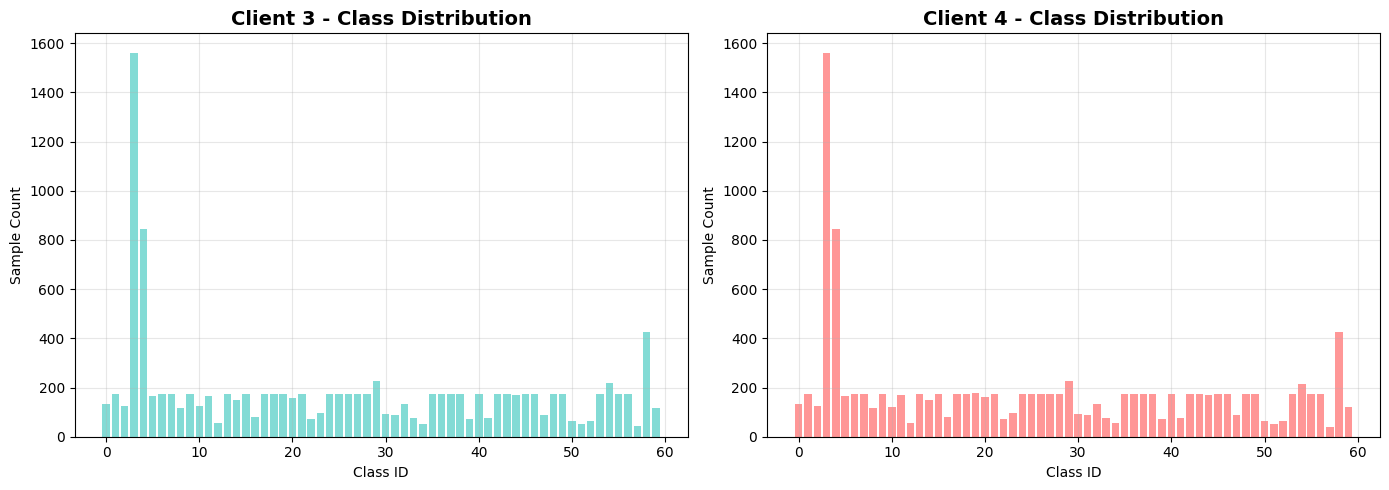

✅ Distribution visualization saved!


In [6]:
print("🔀 Splitting data for Client 3 and Client 4...\n")

# Convert one-hot to class labels for stratification
y_train_labels = y_train.argmax(axis=1)

# 50/50 stratified split
X_client3, X_client4, y_client3, y_client4 = train_test_split(
    X_train,
    y_train,
    test_size=0.5,
    stratify=y_train_labels,
    random_state=42
)

print(f"✅ Data split complete!\n")
print(f"{'='*60}")
print(f"CLIENT 3 (Hospital A):")
print(f"   Training samples: {len(X_client3):,}")
print(f"   Percentage of total: {len(X_client3)/len(X_train)*100:.1f}%")
print(f"   Shape: {X_client3.shape}")

print(f"\nCLIENT 4 (Hospital B):")
print(f"   Training samples: {len(X_client4):,}")
print(f"   Percentage of total: {len(X_client4)/len(X_train)*100:.1f}%")
print(f"   Shape: {X_client4.shape}")
print(f"{'='*60}\n")

# Verify class distribution
y_client3_labels = y_client3.argmax(axis=1)
y_client4_labels = y_client4.argmax(axis=1)

print(f"📊 Class Distribution Verification:\n")
print(f"   Client 3 unique classes: {len(np.unique(y_client3_labels))}/{NUM_CLASSES}")
print(f"   Client 4 unique classes: {len(np.unique(y_client4_labels))}/{NUM_CLASSES}")
print(f"   ✅ Both clients have access to all malware families!\n")

# Visualize distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Client 3 distribution
client3_dist = pd.Series(y_client3_labels).value_counts().sort_index()
axes[0].bar(range(len(client3_dist)), client3_dist.values, alpha=0.7, color='#4ecdc4')
axes[0].set_title('Client 3 - Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class ID')
axes[0].set_ylabel('Sample Count')
axes[0].grid(True, alpha=0.3)

# Client 4 distribution
client4_dist = pd.Series(y_client4_labels).value_counts().sort_index()
axes[1].bar(range(len(client4_dist)), client4_dist.values, alpha=0.7, color='#ff6b6b')
axes[1].set_title('Client 4 - Class Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Class ID')
axes[1].set_ylabel('Sample Count')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(LOCAL_CLIENTS_PATH, 'client_data_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Distribution visualization saved!")

---
## 5️⃣ MODEL ARCHITECTURE (Same as Centralized)

In [7]:
def build_mobilenet_model(img_size=128, num_classes=60):
    """
    Build MobileNetV2-based model.
    EXACT SAME architecture as centralized model for fair comparison.
    """

    inputs = keras.Input(shape=(img_size, img_size, 1))

    # Convert grayscale to RGB
    x = layers.Concatenate()([inputs, inputs, inputs])
    x = layers.Resizing(224, 224)(x)

    # MobileNetV2 base
    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )

    # Freeze first 100 layers
    base_model.trainable = True
    for layer in base_model.layers[:100]:
        layer.trainable = False

    x = base_model(x, training=False)

    # Classification head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name='Local_MalwareDetector')

    return model


print("🏗️ Testing model architecture...\n")
test_model = build_mobilenet_model(IMG_SIZE, NUM_CLASSES)
test_model.summary()

print(f"\n✅ Model architecture verified!")
print(f"   Total parameters: {test_model.count_params():,}")
print(f"   Architecture matches centralized model ✓")

🏗️ Testing model architecture...

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "Local_MalwareDetector"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128, 128,  │          0 │ input_layer[0][0… │
│ (Concatenate)       │ 3)                │            │ input_layer[0][0… │
│                     │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing (Resizing) │ (None, 224, 224,  │          0 │ concatenate[0][0] │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ resizing[0][0]    │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1280)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │    655,872 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512)       │      2,048 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 60)        │     15,420 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,062,652 (11.68 MB)

 Trainable params: 2,665,084 (10.17 MB)

 Non-trainable params: 397,568 (1.52 MB)


✅ Model architecture verified!
   Total parameters: 3,062,652
   Architecture matches centralized model ✓


---
## 6️⃣ TRAIN CLIENT 3 (Hospital A)

**Training on first half of data only**  
**No access to Client 4's data**  
**Expected accuracy: 78-82% (lower than centralized due to less data)**

In [8]:
print(f"\n{'='*80}")
print(f"🏥 TRAINING CLIENT 3 (Hospital A - Isolated)")
print(f"{'='*80}\n")

print(f"📊 Training Configuration:")
print(f"   Training samples: {len(X_client3):,}")
print(f"   Validation samples: {len(X_val):,} (shared)")
print(f"   Test samples: {len(X_test):,} (shared)")
print(f"   Epochs: {EPOCHS_PER_CLIENT}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Estimated time: 2-3 hours on T4 GPU\n")

# Build model
client3_model = build_mobilenet_model(IMG_SIZE, NUM_CLASSES)

# Compute class weights
y_client3_labels = y_client3.argmax(axis=1)
client3_class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_client3_labels),
    y=y_client3_labels
)
client3_class_weights_dict = dict(enumerate(client3_class_weights))

# Compile
client3_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc'), keras.metrics.Precision(), keras.metrics.Recall()]
)

# Data augmentation
datagen_client3 = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

# Callbacks
client3_callbacks = [
    ModelCheckpoint(
        filepath=os.path.join(LOCAL_CLIENTS_PATH, 'client3_best_model.h5'),
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    CSVLogger(
        filename=os.path.join(LOCAL_CLIENTS_PATH, 'client3_training_log.csv'),
        append=False
    )
]

print(f"🚀 Starting Client 3 training...\n")
print(f"⏱️ Started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

# Train
client3_history = client3_model.fit(
    datagen_client3.flow(X_client3, y_client3, batch_size=BATCH_SIZE),
    validation_data=(X_val, y_val),
    epochs=EPOCHS_PER_CLIENT,
    class_weight=client3_class_weights_dict,
    callbacks=client3_callbacks,
    verbose=1
)

print(f"\n✅ Client 3 training complete!")
print(f"⏱️ Finished at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")


🏥 TRAINING CLIENT 3 (Hospital A - Isolated)

📊 Training Configuration:
   Training samples: 10,966
   Validation samples: 4,700 (shared)
   Test samples: 4,700 (shared)
   Epochs: 40
   Batch size: 32
   Estimated time: 2-3 hours on T4 GPU

🚀 Starting Client 3 training...

⏱️ Started at: 2026-04-22 23:15:23

Epoch 1/40
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.0751 - auc: 0.6345 - loss: 4.6779 - precision: 0.1993 - recall: 0.0136
Epoch 1: val_accuracy improved from None to 0.16468, saving model to /content/drive/MyDrive/FYP_Local_Clients/client3_best_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/FYP_Local_Clients/client3_best_model.h5
343/343 ━━━━━━━━━━━━━━━━━━━━ 119s 224ms/step - accuracy: 0.1411 - auc: 0.7221 - loss: 3.9731 - precision: 0.4438 - recall: 0.0403 - val_accuracy: 0.1647 - val_auc: 0.7268 - val_loss: 3.7750 - val_precision: 0.1318 - val_recall: 0.0036 - learning_rate: 1.0000e-04
Epoch 2/40
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.3469 - auc: 0.8809 - loss: 2.6316 - precision: 0.7053 - recall: 0.1695
Epoch 2: val_accuracy did not improve from 0.16468
343/343 ━━━━━━━━━━━━━━━━━━━━ 30s 89ms/step - accuracy: 0.4074 - auc: 0.9047 - loss: 2.3470 - precision: 0.7601 - recall: 0.2271 - val_accuracy: 0.1560 - val_auc: 0.8431 - val_loss: 3.1255 - val_precision: 0.7982 - val_recall: 0.0757 - learning_rate: 1.0000e-04
Epoch 3/40
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.5043 - auc: 0.9410 - loss: 1.8177 - precision: 0.7990 - recall: 0.3532
Epoch 3: val_accuracy improved from 0.16468 to 0.47


Epoch 3: finished saving model to /content/drive/MyDrive/FYP_Local_Clients/client3_best_model.h5
343/343 ━━━━━━━━━━━━━━━━━━━━ 33s 98ms/step - accuracy: 0.5236 - auc: 0.9456 - loss: 1.7360 - precision: 0.8012 - recall: 0.3772 - val_accuracy: 0.4715 - val_auc: 0.9440 - val_loss: 2.0678 - val_precision: 0.9295 - val_recall: 0.2272 - learning_rate: 1.0000e-04
Epoch 4/40
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.5816 - auc: 0.9595 - loss: 1.5085 - precision: 0.8089 - recall: 0.4515
Epoch 4: val_accuracy improved from 0.47149 to 0.52532, saving model to /content/drive/MyDrive/FYP_Local_Clients/client3_best_model.h5



Epoch 4: finished saving model to /content/drive/MyDrive/FYP_Local_Clients/client3_best_model.h5
343/343 ━━━━━━━━━━━━━━━━━━━━ 33s 96ms/step - accuracy: 0.5977 - auc: 0.9637 - loss: 1.4331 - precision: 0.8143 - recall: 0.4710 - val_accuracy: 0.5253 - val_auc: 0.9575 - val_loss: 1.7796 - val_precision: 0.8575 - val_recall: 0.3470 - learning_rate: 1.0000e-04
Epoch 5/40
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.6354 - auc: 0.9709 - loss: 1.2762 - precision: 0.8185 - recall: 0.5104
Epoch 5: val_accuracy improved from 0.52532 to 0.56957, saving model to /content/drive/MyDrive/FYP_Local_Clients/client3_best_model.h5



Epoch 5: finished saving model to /content/drive/MyDrive/FYP_Local_Clients/client3_best_model.h5
343/343 ━━━━━━━━━━━━━━━━━━━━ 33s 96ms/step - accuracy: 0.6467 - auc: 0.9711 - loss: 1.2355 - precision: 0.8269 - recall: 0.5300 - val_accuracy: 0.5696 - val_auc: 0.9607 - val_loss: 1.6739 - val_precision: 0.8941 - val_recall: 0.4328 - learning_rate: 1.0000e-04
Epoch 6/40
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.6790 - auc: 0.9776 - loss: 1.0944 - precision: 0.8430 - recall: 0.5682
Epoch 6: val_accuracy improved from 0.56957 to 0.63106, saving model to /content/drive/MyDrive/FYP_Local_Clients/client3_best_model.h5


...


Epoch 8: finished saving model to /content/drive/MyDrive/FYP_Local_Clients/client3_best_model.h5
343/343 ━━━━━━━━━━━━━━━━━━━━ 34s 100ms/step - accuracy: 0.7273 - auc: 0.9840 - loss: 0.8822 - precision: 0.8597 - recall: 0.6495 - val_accuracy: 0.7383 - val_auc: 0.9821 - val_loss: 0.9994 - val_precision: 0.8980 - val_recall: 0.6200 - learning_rate: 1.0000e-04
Epoch 9/40
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.7367 - auc: 0.9854 - loss: 0.8289 - precision: 0.8578 - recall: 0.6636
Epoch 9: val_accuracy did not improve from 0.73830
343/343 ━━━━━━━━━━━━━━━━━━━━ 31s 89ms/step - accuracy: 0.7422 - auc: 0.9861 - loss: 0.8136 - precision: 0.8609 - recall: 0.6668 - val_accuracy: 0.6923 - val_auc: 0.9827 - val_loss: 1.0684 - val_precision: 0.8955 - val_recall: 0.5634 - learning_rate: 1.0000e-04
Epoch 10/40
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.7658 - auc: 0.9877 - loss: 0.7567 - precision: 0.8752 - recall: 0.6925
Epoch 10: val_accuracy improved from 0.73830 to 0.7


Epoch 10: finished saving model to /content/drive/MyDrive/FYP_Local_Clients/client3_best_model.h5
343/343 ━━━━━━━━━━━━━━━━━━━━ 32s 94ms/step - accuracy: 0.7700 - auc: 0.9875 - loss: 0.7428 - precision: 0.8789 - recall: 0.6982 - val_accuracy: 0.7862 - val_auc: 0.9869 - val_loss: 0.8268 - val_precision: 0.9062 - val_recall: 0.6515 - learning_rate: 1.0000e-04
Epoch 11/40
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.7814 - auc: 0.9884 - loss: 0.7135 - precision: 0.8847 - recall: 0.7063
Epoch 11: val_accuracy did not improve from 0.78617
343/343 ━━━━━━━━━━━━━━━━━━━━ 31s 90ms/step - accuracy: 0.7790 - auc: 0.9882 - loss: 0.7051 - precision: 0.8822 - recall: 0.7117 - val_accuracy: 0.7396 - val_auc: 0.9861 - val_loss: 0.8632 - val_precision: 0.8715 - val_recall: 0.6811 - learning_rate: 1.0000e-04
Epoch 12/40
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.8080 - auc: 0.9908 - loss: 0.6144 - precision: 0.8973 - recall: 0.7462
Epoch 12: val_accuracy improved from 0.78617 to 0


Epoch 12: finished saving model to /content/drive/MyDrive/FYP_Local_Clients/client3_best_model.h5
343/343 ━━━━━━━━━━━━━━━━━━━━ 33s 95ms/step - accuracy: 0.8021 - auc: 0.9906 - loss: 0.6385 - precision: 0.8943 - recall: 0.7397 - val_accuracy: 0.8126 - val_auc: 0.9840 - val_loss: 0.7363 - val_precision: 0.8854 - val_recall: 0.7298 - learning_rate: 1.0000e-04
Epoch 13/40
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.8110 - auc: 0.9898 - loss: 0.6277 - precision: 0.8934 - recall: 0.7545
Epoch 13: val_accuracy improved from 0.81255 to 0.82660, saving model to /content/drive/MyDrive/FYP_Local_Clients/client3_best_model.h5



Epoch 13: finished saving model to /content/drive/MyDrive/FYP_Local_Clients/client3_best_model.h5
343/343 ━━━━━━━━━━━━━━━━━━━━ 34s 99ms/step - accuracy: 0.8125 - auc: 0.9912 - loss: 0.6150 - precision: 0.8973 - recall: 0.7570 - val_accuracy: 0.8266 - val_auc: 0.9892 - val_loss: 0.6252 - val_precision: 0.9019 - val_recall: 0.7906 - learning_rate: 1.0000e-04
Epoch 14/40
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.8229 - auc: 0.9927 - loss: 0.5610 - precision: 0.8995 - recall: 0.7655
Epoch 14: val_accuracy did not improve from 0.82660
343/343 ━━━━━━━━━━━━━━━━━━━━ 30s 87ms/step - accuracy: 0.8196 - auc: 0.9918 - loss: 0.5720 - precision: 0.9002 - recall: 0.7660 - val_accuracy: 0.8266 - val_auc: 0.9880 - val_loss: 0.6505 - val_precision: 0.9054 - val_recall: 0.7538 - learning_rate: 1.0000e-04
Epoch 15/40
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.8214 - auc: 0.9911 - loss: 0.5679 - precision: 0.9036 - recall: 0.7657
Epoch 15: val_accuracy did not improve from 0.826


Epoch 16: finished saving model to /content/drive/MyDrive/FYP_Local_Clients/client3_best_model.h5
343/343 ━━━━━━━━━━━━━━━━━━━━ 31s 89ms/step - accuracy: 0.8390 - auc: 0.9935 - loss: 0.5127 - precision: 0.9102 - recall: 0.7891 - val_accuracy: 0.8372 - val_auc: 0.9836 - val_loss: 0.6294 - val_precision: 0.8908 - val_recall: 0.8102 - learning_rate: 1.0000e-04
Epoch 17/40
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.8403 - auc: 0.9947 - loss: 0.4786 - precision: 0.9066 - recall: 0.7964
Epoch 17: val_accuracy did not improve from 0.83723
343/343 ━━━━━━━━━━━━━━━━━━━━ 30s 88ms/step - accuracy: 0.8449 - auc: 0.9936 - loss: 0.4949 - precision: 0.9111 - recall: 0.8012 - val_accuracy: 0.7251 - val_auc: 0.9819 - val_loss: 0.9404 - val_precision: 0.8603 - val_recall: 0.6815 - learning_rate: 1.0000e-04
Epoch 18/40
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.8492 - auc: 0.9945 - loss: 0.4645 - precision: 0.9118 - recall: 0.8060
Epoch 18: val_accuracy did not improve from 0.837

In [9]:
# Evaluate Client 3 on test set
print(f"🧪 Evaluating Client 3 on test set...\n")

# Load best model
client3_best = keras.models.load_model(os.path.join(LOCAL_CLIENTS_PATH, 'client3_best_model.h5'))

# Evaluate
client3_test_loss, client3_test_acc, client3_test_auc, client3_test_precision, client3_test_recall = \
    client3_best.evaluate(X_test, y_test, verbose=1)

# Calculate F1
client3_test_f1 = 2 * (client3_test_precision * client3_test_recall) / (client3_test_precision + client3_test_recall)

print(f"\n{'='*60}")
print(f"📊 CLIENT 3 TEST RESULTS (Isolated Training)")
print(f"{'='*60}")
print(f"   Accuracy:  {client3_test_acc*100:.2f}%")
print(f"   Precision: {client3_test_precision*100:.2f}%")
print(f"   Recall:    {client3_test_recall*100:.2f}%")
print(f"   F1-Score:  {client3_test_f1*100:.2f}%")
print(f"   AUC:       {client3_test_auc:.4f}")
print(f"   Loss:      {client3_test_loss:.4f}")
print(f"{'='*60}\n")

# Save results
client3_results = {
    'client_id': 3,
    'client_name': 'Hospital A (Image CNN)',
    'training_samples': len(X_client3),
    'test_accuracy': float(client3_test_acc),
    'test_precision': float(client3_test_precision),
    'test_recall': float(client3_test_recall),
    'test_f1': float(client3_test_f1),
    'test_auc': float(client3_test_auc),
    'test_loss': float(client3_test_loss),
    'training_type': 'local_isolated'
}

with open(os.path.join(LOCAL_CLIENTS_PATH, 'client3_results.json'), 'w') as f:
    json.dump(client3_results, f, indent=2)

print(f"✅ Client 3 results saved!")

🧪 Evaluating Client 3 on test set...



147/147 ━━━━━━━━━━━━━━━━━━━━ 16s 60ms/step - accuracy: 0.8389 - auc: 0.9863 - loss: 0.6037 - precision: 0.8898 - recall: 0.8106

📊 CLIENT 3 TEST RESULTS (Isolated Training)
   Accuracy:  83.89%
   Precision: 88.98%
   Recall:    81.06%
   F1-Score:  84.84%
   AUC:       0.9863
   Loss:      0.6037

✅ Client 3 results saved!


---
## 7️⃣ TRAIN CLIENT 4 (Hospital B)

**Training on second half of data only**  
**No access to Client 3's data**  
**Expected accuracy: 78-82% (similar to Client 3)**

In [10]:
print(f"\n{'='*80}")
print(f"🏥 TRAINING CLIENT 4 (Hospital B - Isolated)")
print(f"{'='*80}\n")

print(f"📊 Training Configuration:")
print(f"   Training samples: {len(X_client4):,}")
print(f"   Validation samples: {len(X_val):,} (shared)")
print(f"   Test samples: {len(X_test):,} (shared)")
print(f"   Epochs: {EPOCHS_PER_CLIENT}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Estimated time: 2-3 hours on T4 GPU\n")

# Build model
client4_model = build_mobilenet_model(IMG_SIZE, NUM_CLASSES)

# Compute class weights
y_client4_labels = y_client4.argmax(axis=1)
client4_class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_client4_labels),
    y=y_client4_labels
)
client4_class_weights_dict = dict(enumerate(client4_class_weights))

# Compile
client4_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc'), keras.metrics.Precision(), keras.metrics.Recall()]
)

# Data augmentation
datagen_client4 = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

# Callbacks
client4_callbacks = [
    ModelCheckpoint(
        filepath=os.path.join(LOCAL_CLIENTS_PATH, 'client4_best_model.h5'),
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    CSVLogger(
        filename=os.path.join(LOCAL_CLIENTS_PATH, 'client4_training_log.csv'),
        append=False
    )
]

print(f"🚀 Starting Client 4 training...\n")
print(f"⏱️ Started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

# Train
client4_history = client4_model.fit(
    datagen_client4.flow(X_client4, y_client4, batch_size=BATCH_SIZE),
    validation_data=(X_val, y_val),
    epochs=EPOCHS_PER_CLIENT,
    class_weight=client4_class_weights_dict,
    callbacks=client4_callbacks,
    verbose=1
)

print(f"\n✅ Client 4 training complete!")
print(f"⏱️ Finished at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")


🏥 TRAINING CLIENT 4 (Hospital B - Isolated)

📊 Training Configuration:
   Training samples: 10,966
   Validation samples: 4,700 (shared)
   Test samples: 4,700 (shared)
   Epochs: 40
   Batch size: 32
   Estimated time: 2-3 hours on T4 GPU

🚀 Starting Client 4 training...

⏱️ Started at: 2026-04-22 23:31:56

Epoch 1/40
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.0692 - auc: 0.6320 - loss: 4.6105 - precision_1: 0.2216 - recall_1: 0.0148
Epoch 1: val_accuracy improved from None to 0.19043, saving model to /content/drive/MyDrive/FYP_Local_Clients/client4_best_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/FYP_Local_Clients/client4_best_model.h5
343/343 ━━━━━━━━━━━━━━━━━━━━ 84s 165ms/step - accuracy: 0.1400 - auc: 0.7194 - loss: 3.9486 - precision_1: 0.5073 - recall_1: 0.0443 - val_accuracy: 0.1904 - val_auc: 0.8099 - val_loss: 3.2671 - val_precision_1: 0.8400 - val_recall_1: 0.0089 - learning_rate: 1.0000e-04
Epoch 2/40
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.3459 - auc: 0.8766 - loss: 2.6211 - precision_1: 0.7511 - recall_1: 0.1832
Epoch 2: val_accuracy improved from 0.19043 to 0.41468, saving model to /content/drive/MyDrive/FYP_Local_Clients/client4_best_model.h5



Epoch 2: finished saving model to /content/drive/MyDrive/FYP_Local_Clients/client4_best_model.h5
343/343 ━━━━━━━━━━━━━━━━━━━━ 33s 96ms/step - accuracy: 0.3864 - auc: 0.8964 - loss: 2.4058 - precision_1: 0.7593 - recall_1: 0.2218 - val_accuracy: 0.4147 - val_auc: 0.9018 - val_loss: 2.3994 - val_precision_1: 0.8035 - val_recall_1: 0.1557 - learning_rate: 1.0000e-04
Epoch 3/40
342/343 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.5042 - auc: 0.9363 - loss: 1.8382 - precision_1: 0.7937 - recall_1: 0.3307
Epoch 3: val_accuracy improved from 0.41468 to 0.43404, saving model to /content/drive/MyDrive/FYP_Local_Clients/client4_best_model.h5



Epoch 3: finished saving model to /content/drive/MyDrive/FYP_Local_Clients/client4_best_model.h5
343/343 ━━━━━━━━━━━━━━━━━━━━ 33s 96ms/step - accuracy: 0.5189 - auc: 0.9429 - loss: 1.7602 - precision_1: 0.7988 - recall_1: 0.3625 - val_accuracy: 0.4340 - val_auc: 0.9276 - val_loss: 2.0808 - val_precision_1: 0.7890 - val_recall_1: 0.3023 - learning_rate: 1.0000e-04
Epoch 4/40
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.5548 - auc: 0.9566 - loss: 1.5367 - precision_1: 0.8155 - recall_1: 0.4241
Epoch 4: val_accuracy improved from 0.43404 to 0.43830, saving model to /content/drive/MyDrive/FYP_Local_Clients/client4_best_model.h5



Epoch 4: finished saving model to /content/drive/MyDrive/FYP_Local_Clients/client4_best_model.h5
343/343 ━━━━━━━━━━━━━━━━━━━━ 33s 97ms/step - accuracy: 0.5773 - auc: 0.9605 - loss: 1.4608 - precision_1: 0.8220 - recall_1: 0.4497 - val_accuracy: 0.4383 - val_auc: 0.9410 - val_loss: 2.0943 - val_precision_1: 0.5252 - val_recall_1: 0.3728 - learning_rate: 1.0000e-04
Epoch 5/40
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.6243 - auc: 0.9692 - loss: 1.2813 - precision_1: 0.8326 - recall_1: 0.5032
Epoch 5: val_accuracy improved from 0.43830 to 0.56553, saving model to /content/drive/MyDrive/FYP_Local_Clients/client4_best_model.h5


...


Epoch 25: finished saving model to /content/drive/MyDrive/FYP_Local_Clients/client4_best_model.h5
343/343 ━━━━━━━━━━━━━━━━━━━━ 33s 97ms/step - accuracy: 0.8896 - auc: 0.9965 - loss: 0.3286 - precision_1: 0.9347 - recall_1: 0.8609 - val_accuracy: 0.8428 - val_auc: 0.9884 - val_loss: 0.5439 - val_precision_1: 0.9050 - val_recall_1: 0.7987 - learning_rate: 5.0000e-05
Epoch 26/40
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.8950 - auc: 0.9962 - loss: 0.3302 - precision_1: 0.9357 - recall_1: 0.8639
Epoch 26: val_accuracy improved from 0.84277 to 0.84936, saving model to /content/drive/MyDrive/FYP_Local_Clients/client4_best_model.h5



Epoch 26: finished saving model to /content/drive/MyDrive/FYP_Local_Clients/client4_best_model.h5
343/343 ━━━━━━━━━━━━━━━━━━━━ 33s 95ms/step - accuracy: 0.8929 - auc: 0.9969 - loss: 0.3138 - precision_1: 0.9372 - recall_1: 0.8660 - val_accuracy: 0.8494 - val_auc: 0.9881 - val_loss: 0.5287 - val_precision_1: 0.9015 - val_recall_1: 0.8162 - learning_rate: 5.0000e-05
Epoch 27/40
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.9024 - auc: 0.9971 - loss: 0.2863 - precision_1: 0.9379 - recall_1: 0.8739
Epoch 27: val_accuracy improved from 0.84936 to 0.86000, saving model to /content/drive/MyDrive/FYP_Local_Clients/client4_best_model.h5



Epoch 27: finished saving model to /content/drive/MyDrive/FYP_Local_Clients/client4_best_model.h5
343/343 ━━━━━━━━━━━━━━━━━━━━ 32s 92ms/step - accuracy: 0.8998 - auc: 0.9968 - loss: 0.3027 - precision_1: 0.9397 - recall_1: 0.8717 - val_accuracy: 0.8600 - val_auc: 0.9873 - val_loss: 0.5065 - val_precision_1: 0.9006 - val_recall_1: 0.8345 - learning_rate: 5.0000e-05
Epoch 28/40
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.8971 - auc: 0.9964 - loss: 0.2900 - precision_1: 0.9358 - recall_1: 0.8708
Epoch 28: val_accuracy improved from 0.86000 to 0.87234, saving model to /content/drive/MyDrive/FYP_Local_Clients/client4_best_model.h5



Epoch 28: finished saving model to /content/drive/MyDrive/FYP_Local_Clients/client4_best_model.h5
343/343 ━━━━━━━━━━━━━━━━━━━━ 33s 96ms/step - accuracy: 0.9009 - auc: 0.9966 - loss: 0.2911 - precision_1: 0.9382 - recall_1: 0.8736 - val_accuracy: 0.8723 - val_auc: 0.9883 - val_loss: 0.4707 - val_precision_1: 0.9111 - val_recall_1: 0.8481 - learning_rate: 5.0000e-05
Epoch 29/40
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.8978 - auc: 0.9975 - loss: 0.2897 - precision_1: 0.9373 - recall_1: 0.8749
Epoch 29: val_accuracy did not improve from 0.87234
343/343 ━━━━━━━━━━━━━━━━━━━━ 32s 92ms/step - accuracy: 0.9008 - auc: 0.9974 - loss: 0.2997 - precision_1: 0.9383 - recall_1: 0.8758 - val_accuracy: 0.8440 - val_auc: 0.9861 - val_loss: 0.5491 - val_precision_1: 0.8946 - val_recall_1: 0.8238 - learning_rate: 5.0000e-05
Epoch 30/40
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.9081 - auc: 0.9974 - loss: 0.2680 - precision_1: 0.9404 - recall_1: 0.8815
Epoch 30: val_accuracy di


Epoch 38: finished saving model to /content/drive/MyDrive/FYP_Local_Clients/client4_best_model.h5
343/343 ━━━━━━━━━━━━━━━━━━━━ 34s 99ms/step - accuracy: 0.9242 - auc: 0.9979 - loss: 0.2188 - precision_1: 0.9510 - recall_1: 0.9067 - val_accuracy: 0.8770 - val_auc: 0.9887 - val_loss: 0.4496 - val_precision_1: 0.9043 - val_recall_1: 0.8628 - learning_rate: 2.5000e-05
Epoch 39/40
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9245 - auc: 0.9984 - loss: 0.2063 - precision_1: 0.9514 - recall_1: 0.9061
Epoch 39: val_accuracy did not improve from 0.87702
343/343 ━━━━━━━━━━━━━━━━━━━━ 31s 91ms/step - accuracy: 0.9219 - auc: 0.9981 - loss: 0.2159 - precision_1: 0.9485 - recall_1: 0.9027 - val_accuracy: 0.8649 - val_auc: 0.9858 - val_loss: 0.5100 - val_precision_1: 0.8946 - val_recall_1: 0.8526 - learning_rate: 2.5000e-05
Epoch 40/40
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.9254 - auc: 0.9983 - loss: 0.2162 - precision_1: 0.9517 - recall_1: 0.9056
Epoch 40: val_accuracy di

In [11]:
# Evaluate Client 4 on test set
print(f"🧪 Evaluating Client 4 on test set...\n")

# Load best model
client4_best = keras.models.load_model(os.path.join(LOCAL_CLIENTS_PATH, 'client4_best_model.h5'))

# Evaluate
client4_test_loss, client4_test_acc, client4_test_auc, client4_test_precision, client4_test_recall = \
    client4_best.evaluate(X_test, y_test, verbose=1)

# Calculate F1
client4_test_f1 = 2 * (client4_test_precision * client4_test_recall) / (client4_test_precision + client4_test_recall)

print(f"\n{'='*60}")
print(f"📊 CLIENT 4 TEST RESULTS (Isolated Training)")
print(f"{'='*60}")
print(f"   Accuracy:  {client4_test_acc*100:.2f}%")
print(f"   Precision: {client4_test_precision*100:.2f}%")
print(f"   Recall:    {client4_test_recall*100:.2f}%")
print(f"   F1-Score:  {client4_test_f1*100:.2f}%")
print(f"   AUC:       {client4_test_auc:.4f}")
print(f"   Loss:      {client4_test_loss:.4f}")
print(f"{'='*60}\n")

# Save results
client4_results = {
    'client_id': 4,
    'client_name': 'Hospital B (Image CNN)',
    'training_samples': len(X_client4),
    'test_accuracy': float(client4_test_acc),
    'test_precision': float(client4_test_precision),
    'test_recall': float(client4_test_recall),
    'test_f1': float(client4_test_f1),
    'test_auc': float(client4_test_auc),
    'test_loss': float(client4_test_loss),
    'training_type': 'local_isolated'
}

with open(os.path.join(LOCAL_CLIENTS_PATH, 'client4_results.json'), 'w') as f:
    json.dump(client4_results, f, indent=2)

print(f"✅ Client 4 results saved!")

🧪 Evaluating Client 4 on test set...



147/147 ━━━━━━━━━━━━━━━━━━━━ 17s 67ms/step - accuracy: 0.8828 - auc: 0.9879 - loss: 0.4485 - precision_1: 0.9106 - recall_1: 0.8672

📊 CLIENT 4 TEST RESULTS (Isolated Training)
   Accuracy:  88.28%
   Precision: 91.06%
   Recall:    86.72%
   F1-Score:  88.84%
   AUC:       0.9879
   Loss:      0.4485

✅ Client 4 results saved!


---
## 8️⃣ COMPARISON: Local vs Centralized

In [12]:
# Load centralized results
with open(os.path.join(MODEL_SAVE_PATH, 'test_results.json'), 'r') as f:
    centralized_results = json.load(f)

# Calculate average local performance
avg_local_acc = (client3_test_acc + client4_test_acc) / 2
avg_local_f1 = (client3_test_f1 + client4_test_f1) / 2

# Create comparison table
comparison = pd.DataFrame([
    {
        'Model': 'Client 3 (Local)',
        'Type': 'Isolated',
        'Training Samples': f"{len(X_client3):,}",
        'Accuracy (%)': f"{client3_test_acc*100:.2f}",
        'F1-Score (%)': f"{client3_test_f1*100:.2f}",
        'AUC': f"{client3_test_auc:.4f}"
    },
    {
        'Model': 'Client 4 (Local)',
        'Type': 'Isolated',
        'Training Samples': f"{len(X_client4):,}",
        'Accuracy (%)': f"{client4_test_acc*100:.2f}",
        'F1-Score (%)': f"{client4_test_f1*100:.2f}",
        'AUC': f"{client4_test_auc:.4f}"
    },
    {
        'Model': 'Average Local',
        'Type': 'Isolated',
        'Training Samples': f"{len(X_client3):,} each",
        'Accuracy (%)': f"{avg_local_acc*100:.2f}",
        'F1-Score (%)': f"{avg_local_f1*100:.2f}",
        'AUC': f"{(client3_test_auc + client4_test_auc)/2:.4f}"
    },
    {
        'Model': 'Centralized',
        'Type': 'All Data Pooled',
        'Training Samples': f"{len(X_train):,}",
        'Accuracy (%)': f"{centralized_results['test_accuracy']*100:.2f}",
        'F1-Score (%)': f"{centralized_results['test_f1']*100:.2f}",
        'AUC': f"{centralized_results['test_auc']:.4f}"
    }
])

print(f"\n{'='*100}")
print(f"📊 FINAL COMPARISON: LOCAL (ISOLATED) vs CENTRALIZED")
print(f"{'='*100}\n")
print(comparison.to_string(index=False))
print(f"\n{'='*100}\n")

# Key insights
accuracy_gap = centralized_results['test_accuracy'] - avg_local_acc

print(f"💡 KEY INSIGHTS:\n")
print(f"   🔴 Local clients perform WORSE when isolated:")
print(f"      Average local accuracy: {avg_local_acc*100:.2f}%")
print(f"      Centralized accuracy: {centralized_results['test_accuracy']*100:.2f}%")
print(f"      Performance gap: {accuracy_gap*100:.2f}% lower\n")

print(f"   ✅ This proves the NEED for federated learning:")
print(f"      • Clients can't achieve good accuracy alone (limited data)")
print(f"      • But they can't share data (privacy regulations)")
print(f"      • Federated learning will bridge this gap!\n")

print(f"   🎯 Expected federated learning results:")
print(f"      • Federated global model: ~87-88% accuracy")
print(f"      • Better than isolated local ({avg_local_acc*100:.2f}%)")
print(f"      • Close to centralized ({centralized_results['test_accuracy']*100:.2f}%)")
print(f"      • WITHOUT sharing any raw data! 🔒\n")

# Save comparison
comparison.to_csv(os.path.join(LOCAL_CLIENTS_PATH, 'local_vs_centralized_comparison.csv'), index=False)

# Save summary
summary = {
    'client3_accuracy': float(client3_test_acc),
    'client4_accuracy': float(client4_test_acc),
    'average_local_accuracy': float(avg_local_acc),
    'centralized_accuracy': centralized_results['test_accuracy'],
    'performance_gap': float(accuracy_gap),
    'training_samples_per_client': len(X_client3),
    'total_training_samples': len(X_train)
}

with open(os.path.join(LOCAL_CLIENTS_PATH, 'training_summary.json'), 'w') as f:
    json.dump(summary, f, indent=2)

print(f"✅ Comparison saved!")


📊 FINAL COMPARISON: LOCAL (ISOLATED) vs CENTRALIZED

           Model            Type Training Samples Accuracy (%) F1-Score (%)    AUC
Client 3 (Local)        Isolated           10,966        83.89        84.84 0.9863
Client 4 (Local)        Isolated           10,966        88.28        88.84 0.9879
   Average Local        Isolated      10,966 each        86.09        86.84 0.9871
     Centralized All Data Pooled           21,932        89.28        89.67 0.9920


💡 KEY INSIGHTS:

   🔴 Local clients perform WORSE when isolated:
      Average local accuracy: 86.09%
      Centralized accuracy: 89.28%
      Performance gap: 3.19% lower

   ✅ This proves the NEED for federated learning:
      • Clients can't achieve good accuracy alone (limited data)
      • But they can't share data (privacy regulations)
      • Federated learning will bridge this gap!

   🎯 Expected federated learning results:
      • Federated global model: ~87-88% accuracy
      • Better than isolated local (86.09%)


---
## 9️⃣ VISUALIZATIONS

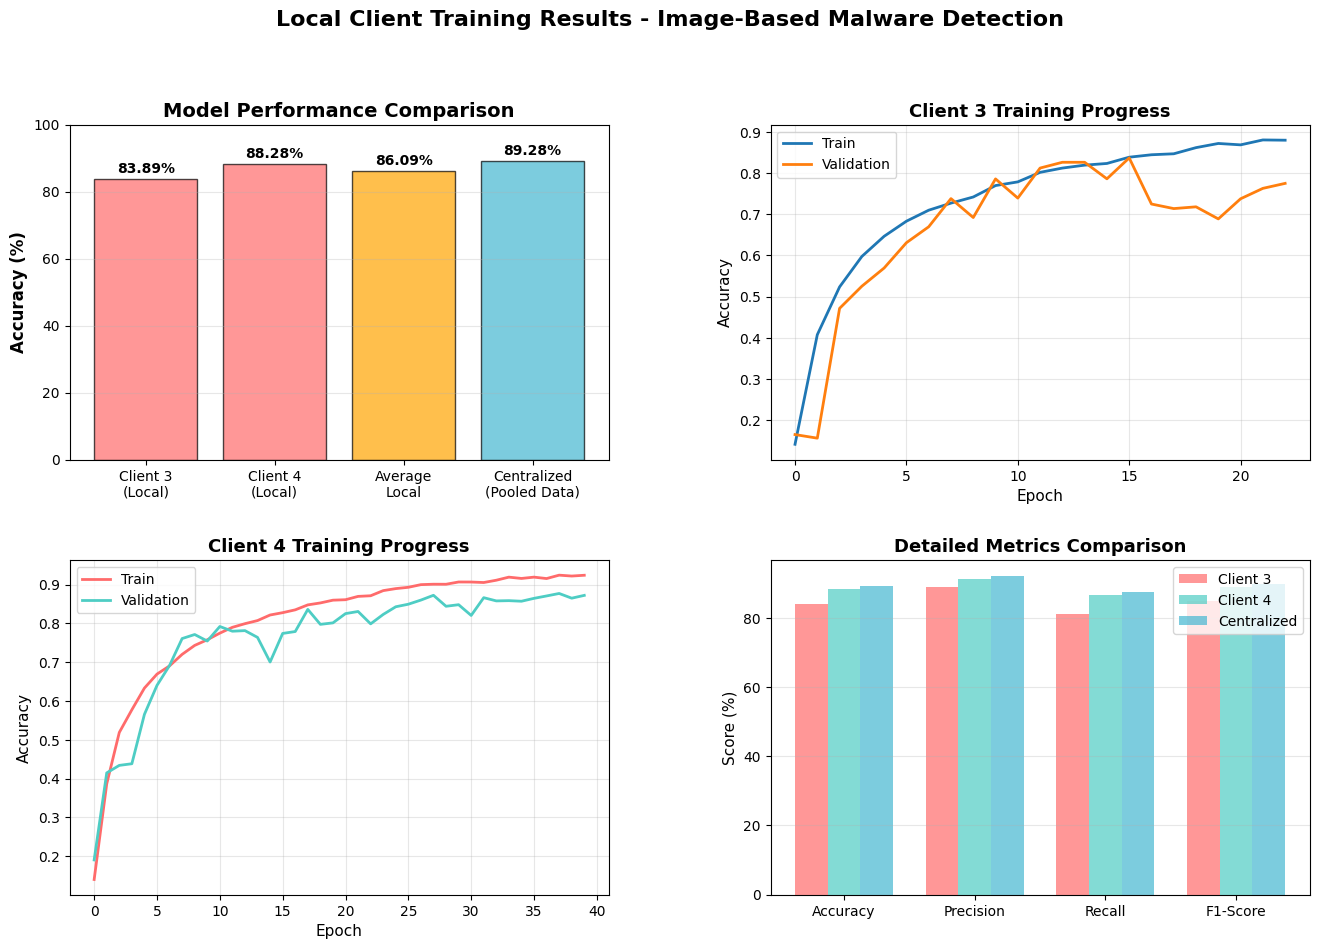

✅ Visualizations saved!


In [13]:
# Create comprehensive visualization
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# 1. Accuracy Comparison
ax1 = fig.add_subplot(gs[0, 0])
models = ['Client 3\n(Local)', 'Client 4\n(Local)', 'Average\nLocal', 'Centralized\n(Pooled Data)']
accuracies = [client3_test_acc*100, client4_test_acc*100, avg_local_acc*100, centralized_results['test_accuracy']*100]
colors = ['#ff6b6b', '#ff6b6b', '#ffa500', '#45b7d1']

bars = ax1.bar(models, accuracies, color=colors, alpha=0.7, edgecolor='black')
ax1.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax1.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim(0, 100)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{height:.2f}%', ha='center', va='bottom', fontweight='bold')

# 2. Training Progress - Client 3
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(client3_history.history['accuracy'], label='Train', linewidth=2)
ax2.plot(client3_history.history['val_accuracy'], label='Validation', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('Accuracy', fontsize=11)
ax2.set_title('Client 3 Training Progress', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Training Progress - Client 4
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(client4_history.history['accuracy'], label='Train', linewidth=2, color='#ff6b6b')
ax3.plot(client4_history.history['val_accuracy'], label='Validation', linewidth=2, color='#4ecdc4')
ax3.set_xlabel('Epoch', fontsize=11)
ax3.set_ylabel('Accuracy', fontsize=11)
ax3.set_title('Client 4 Training Progress', fontsize=13, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Performance Metrics Comparison
ax4 = fig.add_subplot(gs[1, 1])
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
client3_metrics = [client3_test_acc*100, client3_test_precision*100, client3_test_recall*100, client3_test_f1*100]
client4_metrics = [client4_test_acc*100, client4_test_precision*100, client4_test_recall*100, client4_test_f1*100]
centralized_metrics = [
    centralized_results['test_accuracy']*100,
    centralized_results['test_precision']*100,
    centralized_results['test_recall']*100,
    centralized_results['test_f1']*100
]

x = np.arange(len(metrics))
width = 0.25

ax4.bar(x - width, client3_metrics, width, label='Client 3', color='#ff6b6b', alpha=0.7)
ax4.bar(x, client4_metrics, width, label='Client 4', color='#4ecdc4', alpha=0.7)
ax4.bar(x + width, centralized_metrics, width, label='Centralized', color='#45b7d1', alpha=0.7)

ax4.set_ylabel('Score (%)', fontsize=11)
ax4.set_title('Detailed Metrics Comparison', fontsize=13, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(metrics)
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

plt.suptitle('Local Client Training Results - Image-Based Malware Detection',
             fontsize=16, fontweight='bold', y=0.995)

plt.savefig(os.path.join(LOCAL_CLIENTS_PATH, 'comprehensive_results.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Visualizations saved!")

---
## 🔟 FINAL SUMMARY

In [14]:
print(f"\n{'='*100}")
print(f"🎉 LOCAL CLIENT TRAINING COMPLETE!")
print(f"{'='*100}\n")

print(f"📁 All results saved to: {LOCAL_CLIENTS_PATH}\n")

print(f"📂 Generated Files:")
print(f"   ✅ client3_best_model.h5 - Client 3 trained model")
print(f"   ✅ client4_best_model.h5 - Client 4 trained model")
print(f"   ✅ client3_results.json - Client 3 metrics")
print(f"   ✅ client4_results.json - Client 4 metrics")
print(f"   ✅ training_summary.json - Overall summary")
print(f"   ✅ local_vs_centralized_comparison.csv - Comparison table")
print(f"   ✅ comprehensive_results.png - Visualizations")
print(f"   ✅ client_data_distribution.png - Data splits\n")

print(f"📊 Performance Summary:")
print(f"   Client 3 (Isolated): {client3_test_acc*100:.2f}% accuracy")
print(f"   Client 4 (Isolated): {client4_test_acc*100:.2f}% accuracy")
print(f"   Average Local:       {avg_local_acc*100:.2f}% accuracy")
print(f"   Centralized:         {centralized_results['test_accuracy']*100:.2f}% accuracy")
print(f"   Performance Gap:     {accuracy_gap*100:.2f}%\n")

print(f"🚀 Next Steps:")
print(f"   1. ✅ Local clients trained (DONE)")
print(f"   2. ⏳ Implement FedMD federated learning server")
print(f"   3. ⏳ Train federated global model")
print(f"   4. ⏳ Build live dashboard")
print(f"   5. ⏳ Final comparison & report\n")

print(f"💡 Key Insight:")
print(f"   Local clients achieve only {avg_local_acc*100:.2f}% accuracy when isolated.")
print(f"   This is {accuracy_gap*100:.2f}% WORSE than centralized training.")
print(f"   Federated learning will bridge this gap WITHOUT sharing data! 🔒\n")

print(f"{'='*100}\n")

print(f"✅ Ready for FedMD implementation!")
print(f"📥 Download the models and results now.")
print(f"🔜 Next notebook: FedMD_Heterogeneous_Server.ipynb")


🎉 LOCAL CLIENT TRAINING COMPLETE!

📁 All results saved to: /content/drive/MyDrive/FYP_Local_Clients

📂 Generated Files:
   ✅ client3_best_model.h5 - Client 3 trained model
   ✅ client4_best_model.h5 - Client 4 trained model
   ✅ client3_results.json - Client 3 metrics
   ✅ client4_results.json - Client 4 metrics
   ✅ training_summary.json - Overall summary
   ✅ local_vs_centralized_comparison.csv - Comparison table
   ✅ comprehensive_results.png - Visualizations
   ✅ client_data_distribution.png - Data splits

📊 Performance Summary:
   Client 3 (Isolated): 83.89% accuracy
   Client 4 (Isolated): 88.28% accuracy
   Average Local:       86.09% accuracy
   Centralized:         89.28% accuracy
   Performance Gap:     3.19%

🚀 Next Steps:
   1. ✅ Local clients trained (DONE)
   2. ⏳ Implement FedMD federated learning server
   3. ⏳ Train federated global model
   4. ⏳ Build live dashboard
   5. ⏳ Final comparison & report

💡 Key Insight:
   Local clients achieve only 86.09% accuracy when i